### Табличные методы обучения с подкреплением

#### First-Visit MC в GridWorld $2 \times 2$

Рассмотрим среду с состояниями $(i,j)$, где $i,j \in \{0,1\}$.
* Клетка $(1,1)$ — целевое терминальное состояние, переход в него даёт награду $r = +1$.
* Награда за любой нетерминальный шаг составляет $r = -0.04$.
* Действия: $\{\uparrow, \downarrow, \leftarrow, \rightarrow\}$. Движение за границу оставляет агента на месте.
* Коэффициент дисконтирования $\gamma = 0.9$.

Для всех состояний $s$ инициализируем $V_0(s)=0$.

**Эпизод 1.** Допустим эпизод начинается в состоянии $(0,0)$, а траектория $\tau_1$ выглядит так:
$$
(0,0) \xrightarrow{-0.04} (0,1) \xrightarrow{-0.04} (0,0) \xrightarrow{-0.04} (1,0) \xrightarrow{\,\;+1\;\,} (1,1).
$$
Состояние $(0,0)$ посещено дважды: в моменты $t=0$ и $t=2$. Метод First-Visit учитывает только $t=0$:
$$
G_0^1 = -0.04 - 0.9 \cdot 0.04 - 0.9^2 \cdot 0.04 + 0.9^3 \cdot 1 \approx 0.62.
$$
Счётчик $N_1(0,0) = 1$, текущая оценка:
$$
V_1(0,0) = G_0^{(1)} \approx 0.62.
$$

**Эпизод 2.** Допустим агент следуя той же стратегии генерирует траекторию $\tau_2$:
$$
(0,1) \xrightarrow{-0.04} (0,0) \xrightarrow{-0.04} (1,0) \xrightarrow{\;+1.0\;} (1,1).
$$
Первое посещение состояния $(0,0)$ произошло в момент $t=1$:
$$
G_1^2 = -0.04 + 0.9 \cdot 1 = 0.86.
$$
Счётчик $N_2(0,0) = 2$. Новая оценка вычисляется усреднением:
$$
V_2(0,0) = V_1(0,0) + \frac{G_1^2 - V_1(0,0)}{2} \approx 0.62 + \frac{0.86 - 0.62}{2} \approx 0.74.
$$

#### TD(0) в GridWorld $2 \times 2$

Рассмотрим ту же среду. Выберем скорость обучения $\alpha=0.1$. Для всех состояний $s$ инициализируем $V_0(s)=0$.

**Эпизод 1.** Траектория в эпизоде:
$$
(0,0) \xrightarrow{-0.04} (0,1) \xrightarrow{\,\;+1\,\;} (1,1)
$$
* Обновление $k=1$. TD-ошибка и обновление ценности состояния:
   $$
   \delta_1 = -0.04 + 0.9 \cdot V_0(0,1) - V_0(0,0) = -0.04,
   $$
   $$
   V_1(0,0) = 0 - 0.1 \cdot 0.04 = -0.004.
   $$
* Обновление $k=2$. Переход в терминальное состояние $(1,1)$.
   $$
   \delta_2 = 1 + 0.9 \cdot 0 - V_1(0,1) = 1.
   $$
   $$
   V_2(0,1) = 0 + 0.1 \cdot 1 = 0.1.
   $$

**Эпизод 2.** Пусть из начального состояния $(0,0)$ среда переходит в состояние $(0,1)$.
$$
\delta_3 = -0.04 + 0.9 \cdot V_2(0,1) - V_2(0,0) = 0.054.
$$
$$
V_3(0,0) = -0.004 + 0.1 \cdot 0.054 = 0.0014.
$$
В отличие от методов Монте-Карло, которые обновляют оценки пачкой в конце эпизода, TD(0) осуществляет **обратное распространение ценности** (value backpropagation) шаг за шагом.

#### Оценка стратегии на среде `FrozenLake-v1`

Сравнение динамики ошибки $\text{RMSE}(V_k, V^\pi)$ для алгоритмов First-Visit MC, Every-Visit MC, TD(0), $n$-step TD и TD($\lambda$).

First-Visit MC completed
Every-Visit MC completed
TD(0) completed
3-step TD completed
TD($\lambda$) completed


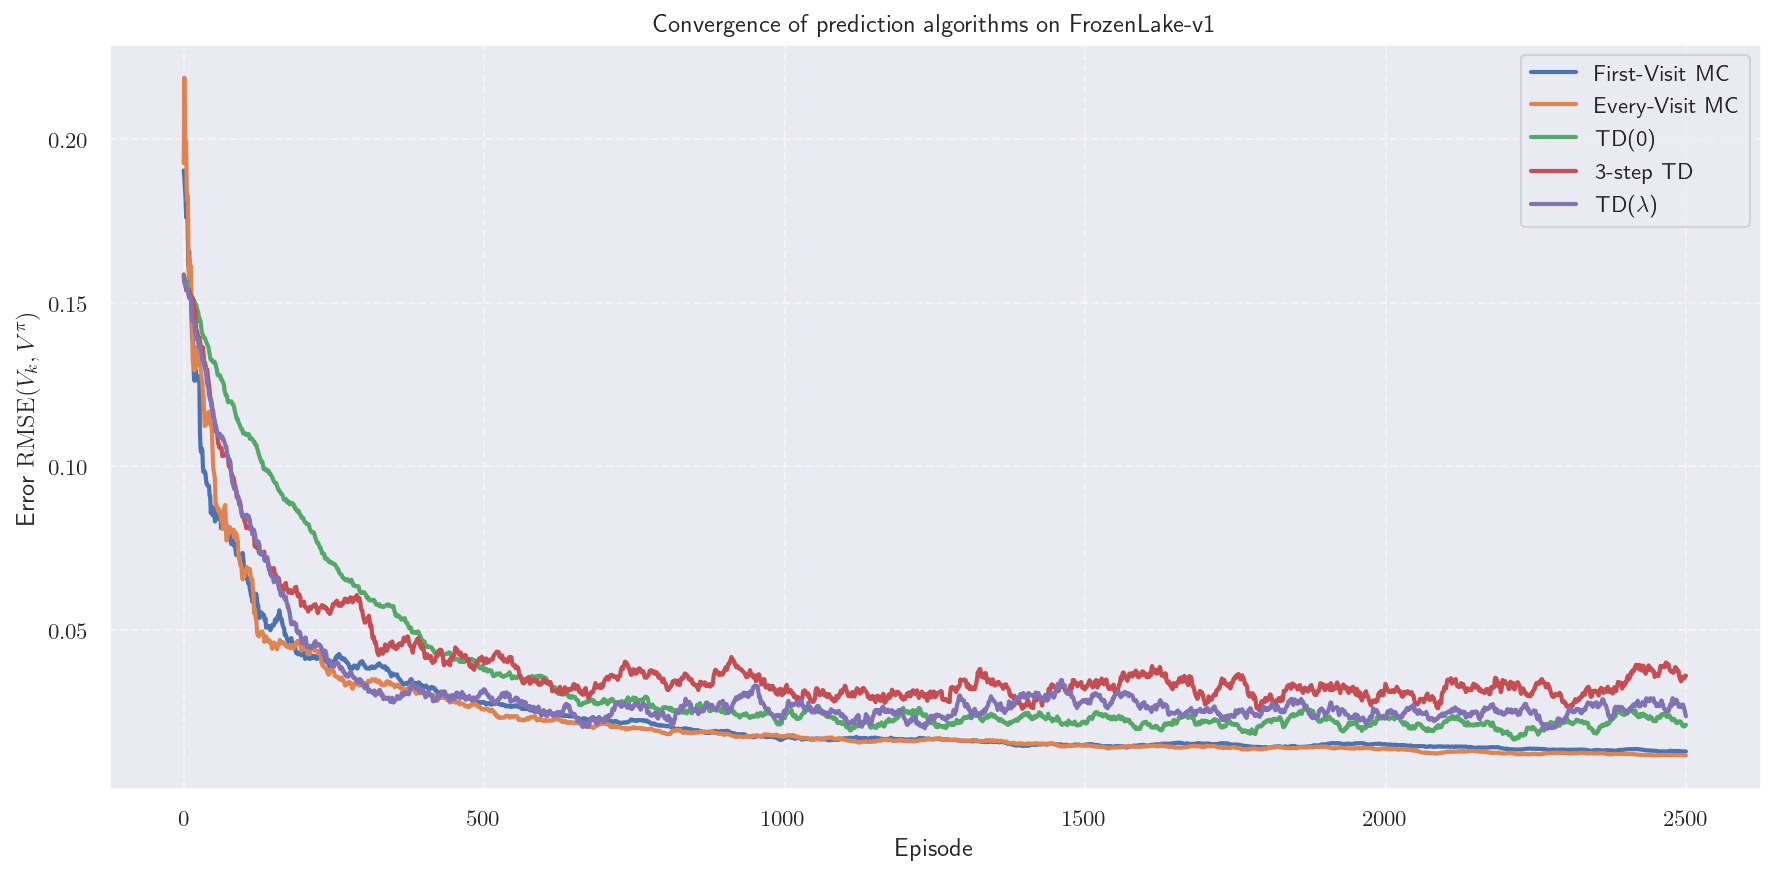

In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme()
plt.rcParams.update({'text.usetex': True})


# ==========================================
# Вычисление истинной функции V^pi
# ==========================================
def compute_true_v(env, pi, gamma=0.95, tol=1e-8):
    """Вычисление функции V^pi через динамическое программирование."""
    n_states = env.observation_space.n
    V = np.zeros(n_states)
    
    # Доступ к матрице переходов unwrapped среды
    P = env.unwrapped.P
    
    while True:
        delta = 0.0
        for s in range(n_states):
            V_old = V[s]
            a = pi[s]
            V_new = 0.0
            
            # Суммирование по всем возможным исходам перехода
            for prob, next_s, reward, terminated in P[s][a]:
                V_new += prob * (reward + gamma * (0.0 if terminated else V[next_s]))
            V[s] = V_new
            delta = max(delta, abs(V_old - V[s]))
        if delta < tol:
            break
    return V

def first_visit_mc(env, pi, episodes, gamma):
    n_states = env.observation_space.n
    V = np.zeros(n_states)
    N = np.zeros(n_states, dtype=int)
    history_V = np.zeros((episodes, n_states))
    
    for ep in range(episodes):
        trajectory, (s, _), done = [], env.reset(), False
        while not done:
            next_s, r, terminated, truncated, _ = env.step(pi[s])
            done = terminated or truncated
            trajectory.append((s, r))
            s = next_s
            
        G = 0.0
        returns = np.zeros(len(trajectory))
        for t in reversed(range(len(trajectory))):
            G = trajectory[t][1] + gamma * G
            returns[t] = G
            
        visited = set()
        for t in range(len(trajectory)):
            st = trajectory[t][0]
            if st not in visited:
                visited.add(st)
                N[st] += 1
                V[st] += (returns[t] - V[st]) / N[st]
        history_V[ep] = V.copy()
    return history_V

def every_visit_mc(env, pi, episodes, gamma):
    n_states = env.observation_space.n
    V = np.zeros(n_states)
    N = np.zeros(n_states, dtype=int)
    history_V = np.zeros((episodes, n_states))
    
    for ep in range(episodes):
        trajectory, (s, _), done = [], env.reset(), False
        while not done:
            next_s, r, terminated, truncated, _ = env.step(pi[s])
            done = terminated or truncated
            trajectory.append((s, r))
            s = next_s
            
        G = 0.0
        returns = np.zeros(len(trajectory))
        for t in reversed(range(len(trajectory))):
            G = trajectory[t][1] + gamma * G
            returns[t] = G
            
        for t in range(len(trajectory)):
            st = trajectory[t][0]
            N[st] += 1
            V[st] += (returns[t] - V[st]) / N[st]
        history_V[ep] = V.copy()
    return history_V

def td_zero(env, pi, episodes, gamma, alpha=0.05):
    n_states = env.observation_space.n
    V = np.zeros(n_states)
    history_V = np.zeros((episodes, n_states))
    
    for ep in range(episodes):
        s, _ = env.reset()
        done = False
        while not done:
            next_s, r, terminated, truncated, _ = env.step(pi[s])
            done = terminated or truncated
            V_next = 0.0 if terminated else V[next_s]
            V[s] += alpha * (r + gamma * V_next - V[s])
            s = next_s
        history_V[ep] = V.copy()
    return history_V

def n_step_td(env, pi, episodes, gamma, n=3, alpha=0.05):
    n_states = env.observation_space.n
    V = np.zeros(n_states)
    history_V = np.zeros((episodes, n_states))
    
    for ep in range(episodes):
        # Генерация эпизода
        states, rewards = [], []
        s, _ = env.reset()
        done = False
        
        while not done:
            next_s, r, terminated, truncated, _ = env.step(pi[s])
            done = terminated or truncated
            states.append(s)
            rewards.append(r)
            s = next_s
        states.append(s)
        
        # Вычисление n-шаговых обновлений для каждого шага t
        T = len(rewards)
        for t in range(T):
            # Суммирование полученных наград на горизонте до n шагов
            G = sum(gamma**i * rewards[t + i] for i in range(min(n, T - t)))
            
            # Бутстрэппинг: добавляем оценку через n шагов
            if t + n < T:
                G += (gamma**n) * V[states[t + n]]
                
            V[states[t]] += alpha * (G - V[states[t]])
            
        history_V[ep] = V.copy()
        
    return history_V

def td_lambda(env, pi, episodes, gamma, lambd=0.6, alpha=0.05):
    n_states = env.observation_space.n
    V = np.zeros(n_states)
    history_V = np.zeros((episodes, n_states))
    
    for ep in range(episodes):
        E = np.zeros(n_states)  # Вектор следов приемлемости (eligibility traces)
        s, _ = env.reset()
        done = False
        
        while not done:
            next_s, r, terminated, truncated, _ = env.step(pi[s])
            done = terminated or truncated
            
            V_next = 0.0 if terminated else V[next_s]
            delta = r + gamma * V_next - V[s]
            
            # Аккумулирующий след
            E[s] += 1.0
            
            # Обновление всех состояний, затронутых следом
            V += alpha * delta * E
            E = gamma * lambd * E
            
            s = next_s
        history_V[ep] = V.copy()
    return history_V

def benchmark_prediction():
    env = gym.make("FrozenLake-v1", is_slippery=True)
    n_states = env.observation_space.n
    gamma = 0.95
    episodes = 2500
    n_seeds = 15

    np.random.seed(42)
    pi_eval = np.random.randint(0, 4, size=n_states)
    V_true = compute_true_v(env, pi_eval, gamma=gamma)

    algos = {
        r"First-Visit MC": lambda: first_visit_mc(env, pi_eval, episodes, gamma),
        r"Every-Visit MC": lambda: every_visit_mc(env, pi_eval, episodes, gamma),
        r"TD(0)": lambda: td_zero(env, pi_eval, episodes, gamma, alpha=0.05),
        r"3-step TD": lambda: n_step_td(env, pi_eval, episodes, gamma, n=3, alpha=0.05),
        r"TD($\lambda$)": lambda: td_lambda(env, pi_eval, episodes, gamma, lambd=0.6, alpha=0.05),
    }

    plt.figure(figsize=(12, 6), dpi=150)

    for name, fn in algos.items():
        rmse_all = []

        for seed in range(n_seeds):
            np.random.seed(seed)
            hist_V = fn()
            rmse = np.sqrt(np.mean((hist_V - V_true) ** 2, axis=1))
            rmse_all.append(rmse)

        mean_rmse = np.mean(rmse_all, axis=0)
        plt.plot(mean_rmse, label=name, lw=2)

        print(f"{name} completed")

    plt.title(r"Convergence of prediction algorithms on FrozenLake-v1")
    plt.xlabel(r"Episode")
    plt.ylabel(r"Error $\mathrm{RMSE}(V_k, V^\pi)$")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

    env.close()

benchmark_prediction()

#### Управление в среде `CliffWalking-v1`

First-Visit MC Control completed
Every-Visit MC Control completed
SARSA completed
Q-learning completed


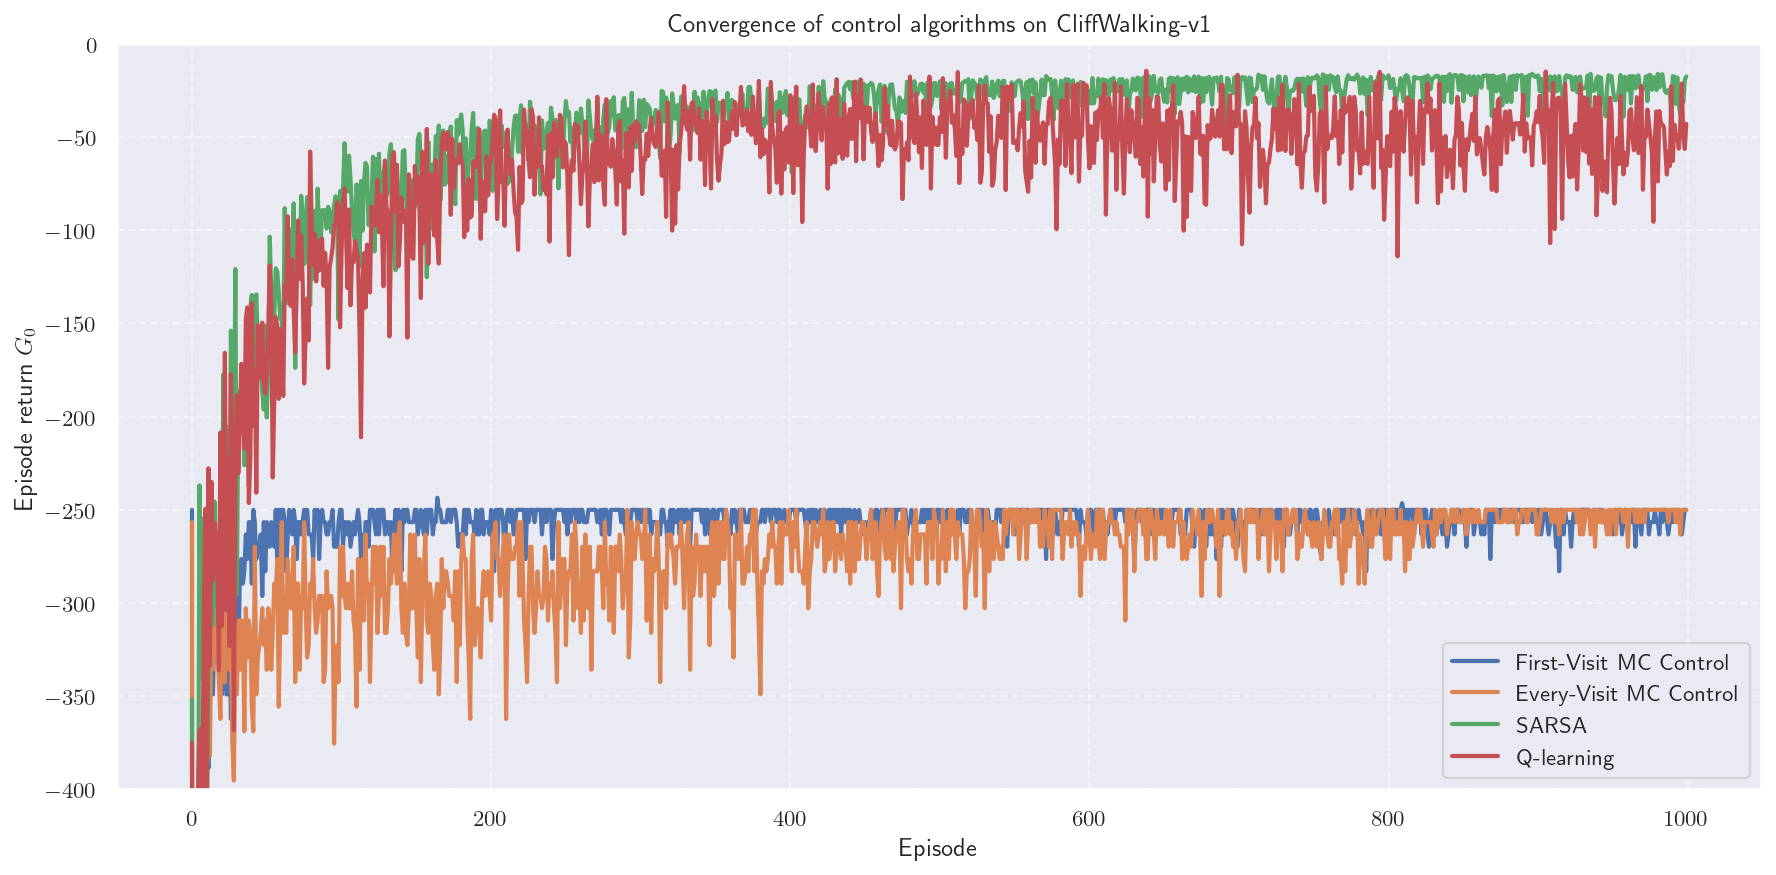

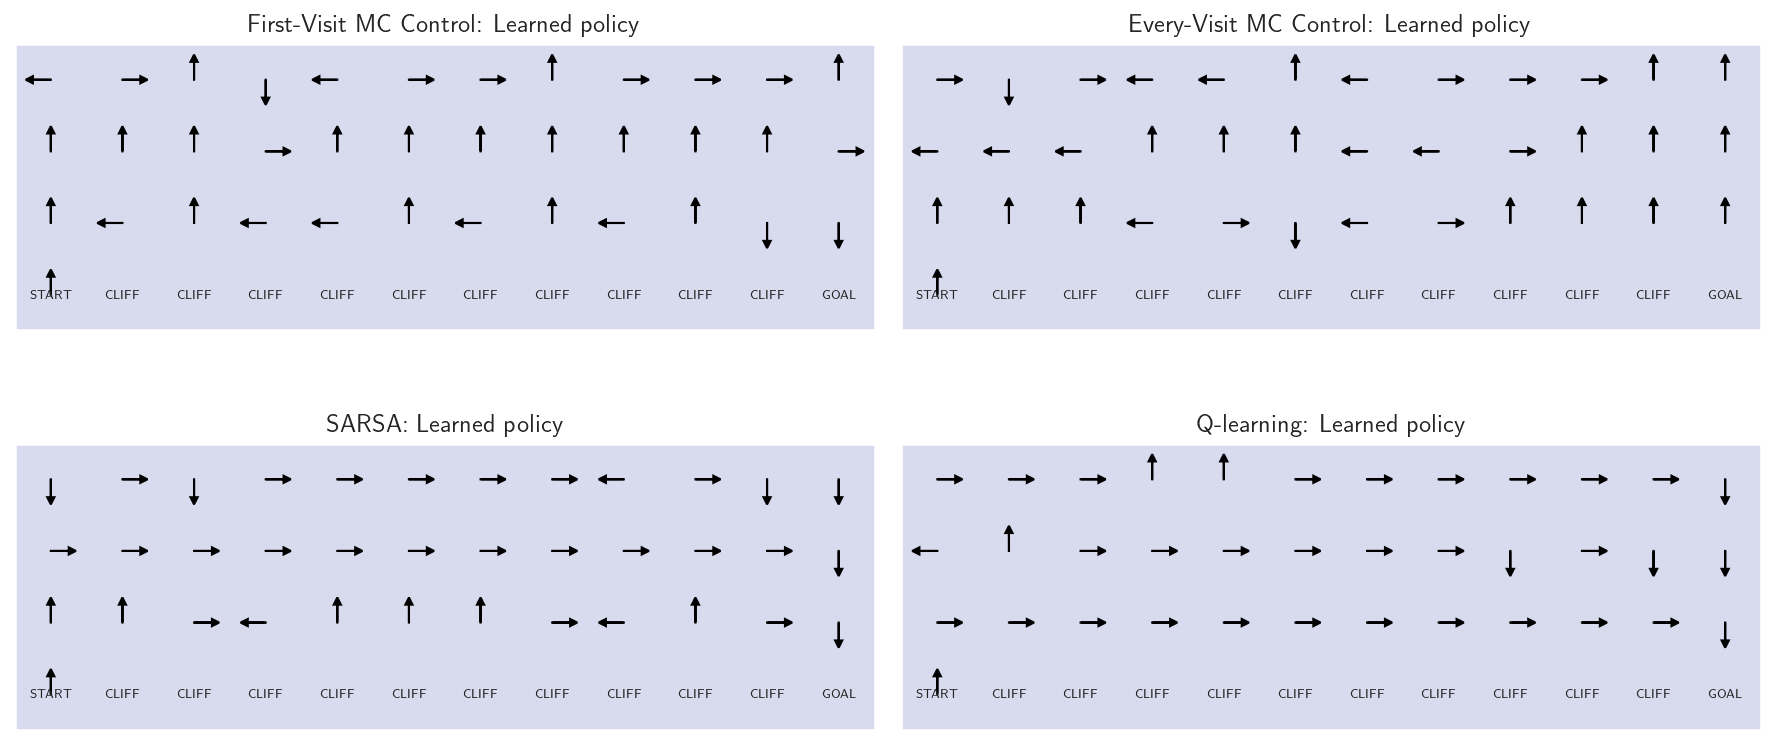

In [3]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

def mc_control_first(env, episodes, gamma=0.95, eps=0.1):
    n_s, n_a = env.observation_space.n, env.action_space.n
    Q = np.zeros((n_s, n_a))
    N = np.zeros((n_s, n_a), dtype=int)
    rewards_hist = np.zeros(episodes)
    
    for ep in range(episodes):
        trajectory, (s, _), done = [], env.reset(), False
        ep_reward = 0
        while not done:
            a = env.action_space.sample() if np.random.random() < eps else int(np.argmax(Q[s]))
            next_s, r, terminated, truncated, _ = env.step(a)
            done = terminated or truncated
            trajectory.append((s, a, r))
            ep_reward += r
            s = next_s
            
        rewards_hist[ep] = ep_reward
        G = 0.0
        returns = np.zeros(len(trajectory))
        for t in reversed(range(len(trajectory))):
            G = trajectory[t][2] + gamma * G
            returns[t] = G
            
        visited_sa = set()
        for t in range(len(trajectory)):
            s_t, a_t, _ = trajectory[t]
            if (s_t, a_t) not in visited_sa:
                visited_sa.add((s_t, a_t))
                N[s_t, a_t] += 1
                Q[s_t, a_t] += (returns[t] - Q[s_t, a_t]) / N[s_t, a_t]
                
    return Q, np.argmax(Q, axis=1), rewards_hist

def mc_control_every(env, episodes, gamma=0.95, eps=0.1):
    n_s, n_a = env.observation_space.n, env.action_space.n
    Q = np.zeros((n_s, n_a))
    N = np.zeros((n_s, n_a), dtype=int)
    rewards_hist = np.zeros(episodes)
    
    for ep in range(episodes):
        trajectory, (s, _), done = [], env.reset(), False
        ep_reward = 0
        while not done:
            a = env.action_space.sample() if np.random.random() < eps else int(np.argmax(Q[s]))
            next_s, r, terminated, truncated, _ = env.step(a)
            done = terminated or truncated
            trajectory.append((s, a, r))
            ep_reward += r
            s = next_s
            
        rewards_hist[ep] = ep_reward
        G = 0.0
        returns = np.zeros(len(trajectory))
        for t in reversed(range(len(trajectory))):
            G = trajectory[t][2] + gamma * G
            returns[t] = G
            
        for t in range(len(trajectory)):
            s_t, a_t, _ = trajectory[t]
            N[s_t, a_t] += 1
            Q[s_t, a_t] += (returns[t] - Q[s_t, a_t]) / N[s_t, a_t]
                
    return Q, np.argmax(Q, axis=1), rewards_hist

def sarsa(env, episodes, gamma=0.95, alpha=0.1, eps=0.1):
    n_s, n_a = env.observation_space.n, env.action_space.n
    Q = np.zeros((n_s, n_a))
    rewards_hist = np.zeros(episodes)
    
    def get_a(s):
        return env.action_space.sample() if np.random.random() < eps else int(np.argmax(Q[s]))
        
    for ep in range(episodes):
        s, _ = env.reset()
        a = get_a(s)
        done = False
        ep_reward = 0
        
        while not done:
            next_s, r, terminated, truncated, _ = env.step(a)
            done = terminated or truncated
            ep_reward += r
            
            if terminated:
                target = r
                next_a = None
            else:
                next_a = get_a(next_s)
                target = r + gamma * Q[next_s, next_a]
                
            Q[s, a] += alpha * (target - Q[s, a])
            s, a = next_s, next_a
            
        rewards_hist[ep] = ep_reward
    return Q, np.argmax(Q, axis=1), rewards_hist

def q_learning(env, episodes, gamma=0.95, alpha=0.1, eps=0.1):
    n_s, n_a = env.observation_space.n, env.action_space.n
    Q = np.zeros((n_s, n_a))
    rewards_hist = np.zeros(episodes)
    
    for ep in range(episodes):
        s, _ = env.reset()
        done = False
        ep_reward = 0
        
        while not done:
            a = env.action_space.sample() if np.random.random() < eps else int(np.argmax(Q[s]))
            next_s, r, terminated, truncated, _ = env.step(a)
            done = terminated or truncated
            ep_reward += r
            
            target = r if terminated else r + gamma * np.max(Q[next_s])
            Q[s, a] += alpha * (target - Q[s, a])
            s = next_s
            
        rewards_hist[ep] = ep_reward
    return Q, np.argmax(Q, axis=1), rewards_hist


def plot_gridworld_policy(ax, pi, title):
    """Plot a policy on the 4x12 CliffWalking grid."""
    ax.imshow(np.zeros((4, 12)), cmap="coolwarm", alpha=0.1)

    arrows = {
        0: (0, 0.25),    # Up
        1: (0.25, 0),    # Right
        2: (0, -0.25),   # Down
        3: (-0.25, 0),   # Left
    }

    for r in range(4):
        for c in range(12):
            s = r * 12 + c

            if r == 3 and 1 <= c <= 10:
                ax.text(c, r, "CLIFF", ha="center", va="center", fontsize=6)
                continue

            if r == 3 and c == 11:
                ax.text(c, r, "GOAL", ha="center", va="center", fontsize=6)
                continue

            if r == 3 and c == 0:
                ax.text(c, r, "START", ha="center", va="center", fontsize=6)

            dx, dy = arrows[pi[s]]
            ax.arrow(c, r, dx, -dy, head_width=0.1, head_length=0.1, fc='black', ec='black')

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title)


def benchmark_control():
    env = gym.make("CliffWalking-v1", max_episode_steps=250)
    episodes = 1000
    n_seeds = 15
    gamma = 0.95
    eps = 0.1
    alpha = 0.05

    algos = {
        "First-Visit MC Control": lambda: mc_control_first(
            env, episodes, gamma, eps
        ),
        "Every-Visit MC Control": lambda: mc_control_every(
            env, episodes, gamma, eps
        ),
        "SARSA": lambda: sarsa(
            env, episodes, gamma, alpha, eps
        ),
        "Q-learning": lambda: q_learning(
            env, episodes, gamma, alpha, eps
        ),
    }

    results = {}
    last_policies = {}

    for name, fn in algos.items():
        all_rewards = []

        for seed in range(n_seeds):
            np.random.seed(seed)
            Q, pi, rewards = fn()
            all_rewards.append(rewards)

            if seed == 0:
                last_policies[name] = pi

        results[name] = np.mean(all_rewards, axis=0)
        print(f"{name} completed")

    env.close()

    # Learning curves
    plt.figure(figsize=(12, 6), dpi=150)

    for name, mean_rewards in results.items():
        plt.plot(mean_rewards, label=name, lw=2)

    plt.title("Convergence of control algorithms on CliffWalking-v1")
    plt.xlabel("Episode")
    plt.ylabel("Episode return $G_0$")
    plt.ylim(-400, 0)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Learned policies
    fig, axes = plt.subplots(2, 2, figsize=(12, 6), dpi=150)

    plot_gridworld_policy(
        axes[0, 0],
        last_policies["First-Visit MC Control"],
        "First-Visit MC Control: Learned policy"
    )

    plot_gridworld_policy(
        axes[0, 1],
        last_policies["Every-Visit MC Control"],
        "Every-Visit MC Control: Learned policy"
    )

    plot_gridworld_policy(
        axes[1, 0],
        last_policies["SARSA"],
        "SARSA: Learned policy"
    )

    plot_gridworld_policy(
        axes[1, 1],
        last_policies["Q-learning"],
        "Q-learning: Learned policy"
    )

    plt.tight_layout()
    plt.show()

benchmark_control()

### Сравнительный анализ табличных методов
| Алгоритм          | Оцениваемый объект |  Парадигма | Момент обновления | TD-цель / таргет                                                   |       Смещение       |       Дисперсия      |
| :---------------- | :----------------: | :--------: | :---------------: | :----------------------------------------------------------------- | :------------------: | :------------------: |
| **MC Prediction** |       $V^\pi$      |  On-policy |   Конец эпизода   | $G_t = \sum\limits_{\tau=t}^{T-1} \gamma^{\tau-t} R_{\tau+1}$      |          $0$         |        Высокая       |
| **MC Control**    |   $Q^\pi \to Q^*$  |  On-policy |   Конец эпизода   | $G_t = \sum\limits_{\tau=t}^{T-1} \gamma^{\tau-t} R_{\tau+1}$      |          $0$         |        Высокая       |
| **TD(0)**         |       $V^\pi$      |  On-policy |     Каждый шаг    | $R_{t+1} + \gamma V(S_{t+1})$                                      |         Есть         |        Низкая        |
| **$\boldsymbol n$-step TD**   |       $V^\pi$      |  On-policy |  После $n$ шагов  | $\sum\limits_{i=1}^{n} \gamma^{i-1} R_{t+i} + \gamma^n V(S_{t+n})$ |       Зависит от $n$      |       Зависит от $n$      |
| **TD($\boldsymbol \lambda$)** |       $V^\pi$      |  On-policy |     Каждый шаг    | $(1 - \lambda) \sum\limits_{n=1}^{\infty} \lambda^{n-1} \left(\sum\limits_{i=1}^{n} \gamma^{i-1} R_{t+i} + \gamma^n V(S_{t+n})\right)$                                         | Зависит от $\lambda$ | Зависит от $\lambda$ |
| **SARSA**         |   $Q^\pi \to Q^*$  |  On-policy |     Каждый шаг    | $R_{t+1} + \gamma Q(S_{t+1}, A_{t+1})$                             |         Есть         |        Низкая        |
| **$\boldsymbol Q$-learning**  |        $Q^*$       | Off-policy |     Каждый шаг    | $R_{t+1} + \gamma \max\limits_{a'} Q(S_{t+1},a')$                  |         Есть         |        Низкая        |

